# Vehicle/map generalization and adaptation
## Summary
This notebook reads the fixed primary policy's four-condition generalization result. It also queries completed child policies for paired target improvement and source retention. Missing adaptation evidence stays missing; no inference or training occurs.

In [1]:
import hashlib
import html
import sys
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import HTML, Markdown, display

PROJECT = next(
    path for path in [Path.cwd(), *Path.cwd().parents] if (path / "src/gradientclimb").is_dir()
)
ROOT = PROJECT / "artifacts"
sys.path.insert(0, str(PROJECT / "src"))
sys.path.insert(0, str(PROJECT / "scripts"))
from analyze_research import adaptation_comparisons

from gradientclimb.experiments import list_runs, load_run, verify_run

PRIMARY = "c0a9e142-1ad6-4d88-810d-bda4ca297f40"
CHECKPOINT_EVALUATION = "b8df5a43-deb0-4b3a-917b-2398322c327c"
GENERALIZATION_EVALUATION = "3a9a0c20-e544-4efd-9c68-e2830d8e8224"
plt.rcParams.update(
    {
        "figure.figsize": (9, 4.5),
        "font.size": 11,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.axisbelow": True,
    }
)
COLORS = {"source": "#087f8c", "shift": "#bc5a36", "reference": "#596b75"}


def show_table(headers, rows):
    heading = "".join(
        '<th style="text-align:left;padding:7px">' + html.escape(str(x)) + "</th>" for x in headers
    )
    body = "".join(
        "<tr>"
        + "".join(
            '<td style="padding:7px;border-top:1px solid #ddd;overflow-wrap:anywhere">'
            + html.escape(str(x))
            + "</td>"
            for x in row
        )
        + "</tr>"
        for row in rows
    )
    display(
        HTML(
            '<div style="overflow:auto"><table style="border-collapse:collapse;font-size:13px"><thead><tr>'
            + heading
            + "</tr></thead><tbody>"
            + body
            + "</tbody></table></div>"
        )
    )


primary = load_run(ROOT, PRIMARY)
assert primary["status"] == "completed"
assert verify_run(ROOT, PRIMARY)["valid"]
display(
    Markdown(
        f"**Primary source:** `{PRIMARY}`. Actual training: **{primary['summary']['training_clock_seconds']:.3f} s**; final validation mean **{primary['summary']['mean_distance']:.2f} nominal m**. Real-game qualification remains incomplete."
    )
)

**Primary source:** `c0a9e142-1ad6-4d88-810d-bda4ca297f40`. Actual training: **3600.322 s**; final validation mean **681.55 nominal m**. Real-game qualification remains incomplete.

## Context & methods
The default/train condition uses a fresh procedural seed set. Heavy is a synthetic vehicle profile; rough is a shifted synthetic terrain family. These are not commercial-game vehicles or maps.
### Key assumptions
Generalization uses the same 20 seeds 20000–20019 across conditions. The 60-second horizon is finite. Episode uncertainty is conditional on the fixed policy; one parent/child training seed cannot establish adaptation reliability. Reuse of the same test seeds supports pairing but does not produce independent untouched test sets for later decisions.
## Data
### 1. Verify the generalization record and checkpoint lineage

In [2]:
generalization = load_run(ROOT, GENERALIZATION_EVALUATION)
assert verify_run(ROOT, GENERALIZATION_EVALUATION)["valid"]
assert generalization["parent_checkpoint"] == primary["checkpoint_hash"]
conditions = ["in_distribution", "new_map", "new_vehicle", "new_vehicle_and_map"]
results = {row["metadata"]["condition"]: row for row in generalization["evaluation_results"]}
assert set(results) == set(conditions)
assert all(row["results"]["seeds"] == list(range(20000, 20020)) for row in results.values())
print("Evaluation run:", GENERALIZATION_EVALUATION)
print("Checkpoint SHA-256:", primary["checkpoint_hash"])
print(
    "Record SHA-256:",
    hashlib.sha256(
        (ROOT / "runs" / GENERALIZATION_EVALUATION / "run.json").read_bytes()
    ).hexdigest(),
)

Evaluation run: 3a9a0c20-e544-4efd-9c68-e2830d8e8224
Checkpoint SHA-256: 87c469539110d3134c04ebcf11e95f9c84e595c90ba7e6b2b106917115e04ec0
Record SHA-256: a40c4b60bc6fca887431104707438b852c6a84090fdc3fa7ef3ef9b745113a1b


## Results
### 2. Compare distance and survival outcomes

In [3]:
show_table(
    ["Condition", "Mean / median nominal m", "Mean survival s", "Termination fractions"],
    [
        [
            condition,
            f"{results[condition]['results']['mean_distance']:.2f} / {results[condition]['results']['median_distance']:.2f}",
            f"{results[condition]['results']['summary']['survival_seconds']['mean']:.2f}",
            results[condition]["results"]["summary"]["failure_rates"],
        ]
        for condition in conditions
    ],
)

Condition,Mean / median nominal m,Mean survival s,Termination fractions
in_distribution,700.75 / 703.66,60.00,{'time_limit': 1.0}
new_map,122.30 / 97.29,19.38,"{'crash': 0.9, 'stalled': 0.05, 'time_limit': 0.05}"
new_vehicle,681.62 / 698.89,60.00,{'time_limit': 1.0}
new_vehicle_and_map,146.88 / 108.79,24.17,"{'crash': 0.85, 'time_limit': 0.15}"


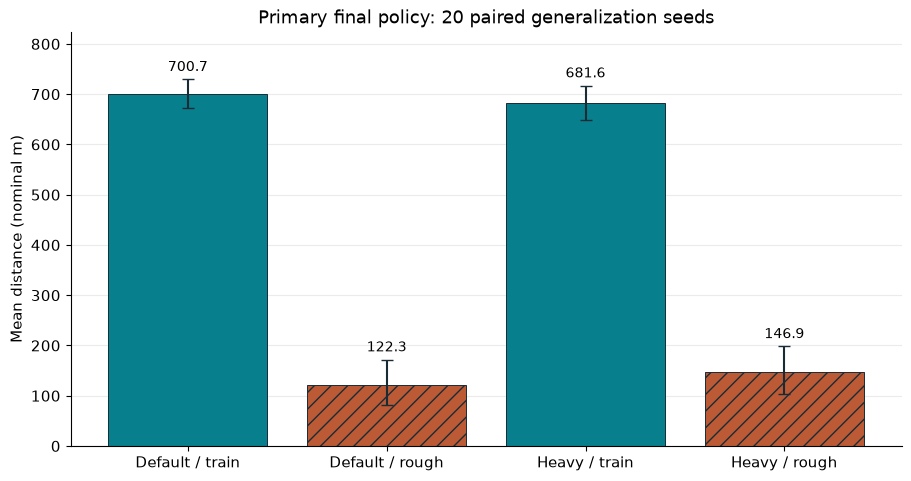

In [4]:
labels = ["Default / train", "Default / rough", "Heavy / train", "Heavy / rough"]
distances = [results[c]["results"]["summary"]["distance"] for c in conditions]
positions = list(range(4))
fig, axis = plt.subplots(figsize=(9, 4.7), layout="constrained")
bars = axis.bar(
    positions,
    [d["mean"] for d in distances],
    color=[COLORS["source"], COLORS["shift"], COLORS["source"], COLORS["shift"]],
    edgecolor="#192b35",
    linewidth=0.7,
)
for index, bar in enumerate(bars):
    if index % 2:
        bar.set_hatch("//")
axis.errorbar(
    positions,
    [d["mean"] for d in distances],
    yerr=[
        [d["mean"] - d["ci95_low"] for d in distances],
        [d["ci95_high"] - d["mean"] for d in distances],
    ],
    fmt="none",
    ecolor="#192b35",
    capsize=4,
)
axis.set_xticks(positions, labels)
axis.set(
    ylabel="Mean distance (nominal m)", title="Primary final policy: 20 paired generalization seeds"
)
axis.set_ylim(0, max(d["ci95_high"] for d in distances) * 1.13)
axis.grid(axis="y", alpha=0.25)
for index, distance in enumerate(distances):
    axis.annotate(
        f"{distance['mean']:.1f}",
        (index, distance["ci95_high"]),
        xytext=(0, 6),
        textcoords="offset points",
        ha="center",
        fontsize=10,
    )
plt.show()

### 3. Query actual completed adaptation evidence
The reusable report pairing helper requires matching checkpoints, scenario, horizon, simulator/calibration version, deterministic setting and episode seeds. Positive changes favor the child. Default/train measures retention on the original source condition.

In [5]:
records = list_runs(ROOT)
completed = [r for r in records if r["status"] == "completed"]
evaluations = [dict(row, run_id=r["run_id"]) for r in completed for row in r["evaluation_results"]]
comparisons = [
    row
    for row in adaptation_comparisons(completed, evaluations)
    if row["parent_training_run"] == PRIMARY
]
if comparisons:
    show_table(
        [
            "Child run",
            "Condition",
            "Before / after mean m",
            "Paired change m",
            "Paired episode CI95%",
        ],
        [
            [
                row["child_training_run"],
                row["condition"],
                f"{row['before_mean']:.2f} / {row['after_mean']:.2f}",
                f"{row['difference_after_minus_before']['distance_difference']['mean']:+.2f}",
                f"[{row['difference_after_minus_before']['distance_difference']['ci95_low']:.2f}, {row['difference_after_minus_before']['distance_difference']['ci95_high']:.2f}]",
            ]
            for row in comparisons
        ],
    )
else:
    print(
        "No matching completed parent/child generalization pairs are recorded yet. Adaptation and forgetting are not yet measured."
    )

No matching completed parent/child generalization pairs are recorded yet. Adaptation and forgetting are not yet measured.


## Takeaways

In [6]:
source = results["in_distribution"]["results"]["mean_distance"]
rough = results["new_map"]["results"]["mean_distance"]
heavy = results["new_vehicle"]["results"]["mean_distance"]
crash = results["new_map"]["results"]["summary"]["failure_rates"].get("crash", 0)
display(
    Markdown(
        f"On this fixed 20-seed result, rough terrain reduced mean distance from **{source:.2f}** to **{rough:.2f}** nominal m, with crashes in **{crash:.0%}** of episodes. The heavy vehicle on training terrain averaged **{heavy:.2f}** nominal m. This is evidence of a terrain-shift weakness in the surrogate, not a measured commercial-game transfer ratio. Longer unexecuted adaptation budgets remain missing."
    )
)

On this fixed 20-seed result, rough terrain reduced mean distance from **700.75** to **122.30** nominal m, with crashes in **90%** of episodes. The heavy vehicle on training terrain averaged **681.62** nominal m. This is evidence of a terrain-shift weakness in the surrogate, not a measured commercial-game transfer ratio. Longer unexecuted adaptation budgets remain missing.